# Notebook 04 — Machine Learning Supervisado: XGBoost y LightGBM
**TFM · Predicción de Ventas para Optimización de Stock**
Familias: PVC · PE · PE-X (reticulado)

**Objetivos:**
1. Feature engineering temporal: lags, medias móviles, variables de calendario
2. Ajuste de XGBoost y LightGBM con TimeSeriesSplit CV
3. Tuning de hiperparámetros con RandomizedSearchCV
4. Predicción recursiva multistep con intervalos bootstrap
5. Interpretabilidad con valores SHAP
6. Comparativa con los modelos estadísticos del Notebook 03

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import xgboost as xgb
import lightgbm as lgb
import shap

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error
)

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

FAMILIAS = None
COLORES  = {'PVC': '#2ecc71', 'PE': '#3498db', 'PE-X': '#e74c3c'}
H        = 12     # horizonte de prediccion (meses)
ALPHA    = 0.05   # nivel IC bootstrap
N_BOOT   = 500    # replicas bootstrap para IC
N_ITER   = 30     # iteraciones RandomizedSearchCV

print('Imports OK')
print(f'XGBoost {xgb.__version__}  |  LightGBM {lgb.__version__}')

Imports OK
XGBoost 3.2.0  |  LightGBM 4.6.0


## 1. Carga de datos

In [2]:
df = pd.read_excel('../data/processed/datos.xlsx')
df['FECHA'] = pd.to_datetime(df['FECHA'])

df_ventas = df[df['TIPO_OPERACION'] == 'VENTA'].copy()
df_ventas['PERIODO'] = df_ventas['FECHA'].dt.to_period('M')

ventas_mensual = (
    df_ventas
    .groupby(['PERIODO', 'FAMILIA'])['PESO_BRUTO']
    .sum()
    .unstack('FAMILIA')
    .sort_index()
    .fillna(0)
)

FAMILIAS = ventas_mensual.columns.tolist()   # ← esto primero
print(f'Periodo: {ventas_mensual.index[0]} -> {ventas_mensual.index[-1]}')
print(f'Total meses: {len(ventas_mensual)}')
print(f'Familias: {FAMILIAS}')

# Umbral del 90% para detectar meses con venta extrema, por familia
umbral_extremo = {}
for fam in FAMILIAS:                          # ← ahora FAMILIAS ya existe
    umbral_extremo[fam] = ventas_mensual[fam].quantile(0.90)

print('\nUmbrales de evento extremo (percentil 90):')
for fam, u in umbral_extremo.items():
    print(f'  {fam}: {u:,.0f}')

ventas_mensual.describe().round(0)

Periodo: 2010-12 -> 2026-02
Total meses: 163
Familias: [106, 124, 233]

Umbrales de evento extremo (percentil 90):
  106: 17,870
  124: 57,450
  233: 92,702


FAMILIA,106,124,233
count,163.0,163.0,163.0
mean,5631.0,20449.0,42324.0
std,12854.0,25120.0,33583.0
min,0.0,0.0,0.0
25%,0.0,0.0,14884.0
50%,0.0,11172.0,35782.0
75%,4806.0,36055.0,60029.0
max,71347.0,107886.0,139563.0


## 2. Feature Engineering Temporal

Los modelos de árboles no tienen memoria temporal intrínseca.
Toda la estructura de la serie debe codificarse explícitamente como columnas.

Se crean tres bloques de features:
- **Lags**: valores pasados de la propia serie (memoria directa)
- **Estadísticos de ventana móvil**: media y desviación sobre ventanas de 3, 6 y 12 meses
- **Calendario**: mes, trimestre, año y codificación circular (sin/cos) del mes

In [3]:
def crear_features(serie, lags=[1, 2, 3, 6, 12], ventanas=[3, 6, 12]):
    """
    Construye un DataFrame de features a partir de una serie temporal.
    Mantiene el conjunto original — los experimentos confirmaron que
    añadir lag_24, volat_ratio o fue_extremo no mejora el rendimiento
    con el tamaño de muestra disponible (~150-190 meses).
    """
    df = pd.DataFrame({'y': serie.values}, index=serie.index)

    for lag in lags:
        df[f'lag_{lag}'] = df['y'].shift(lag)

    for v in ventanas:
        df[f'ma_{v}']  = df['y'].shift(1).rolling(v).mean()
        df[f'std_{v}'] = df['y'].shift(1).rolling(v).std()

    df['mes']       = [p.month       for p in serie.index]
    df['trimestre'] = [((p.month-1)//3)+1 for p in serie.index]
    df['ano']       = [p.year        for p in serie.index]
    df['mes_sin']   = np.sin(2 * np.pi * df['mes'] / 12)
    df['mes_cos']   = np.cos(2 * np.pi * df['mes'] / 12)
    df['trend']     = np.arange(len(df))

    return df.dropna()


# ── Datasets sobre serie ORIGINAL (para test/evaluación) ──────────────────────
datasets = {}
for familia in FAMILIAS:
    df_f = crear_features(ventas_mensual[familia])
    datasets[familia] = df_f
    print(f'[{familia}]  filas={len(df_f)}  features={df_f.shape[1]-1}')

print('\nColumnas de features:')
print(list(datasets[FAMILIAS[0]].drop(columns='y').columns))


# ── Datasets sobre serie WINSORIZADA (para entrenamiento) ─────────────────────
from scipy.stats.mstats import winsorize

ventas_mensual_wins = ventas_mensual.copy()
for fam in FAMILIAS:
    ventas_mensual_wins[fam] = winsorize(ventas_mensual[fam], limits=[0, 0.05])

datasets_wins = {}
for familia in FAMILIAS:
    datasets_wins[familia] = crear_features(ventas_mensual_wins[familia])

print('\nDatasets winsorizados creados (solo para entrenamiento).')

[106]  filas=151  features=17
[124]  filas=151  features=17
[233]  filas=151  features=17

Columnas de features:
['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'ma_3', 'std_3', 'ma_6', 'std_6', 'ma_12', 'std_12', 'mes', 'trimestre', 'ano', 'mes_sin', 'mes_cos', 'trend']

Datasets winsorizados creados (solo para entrenamiento).


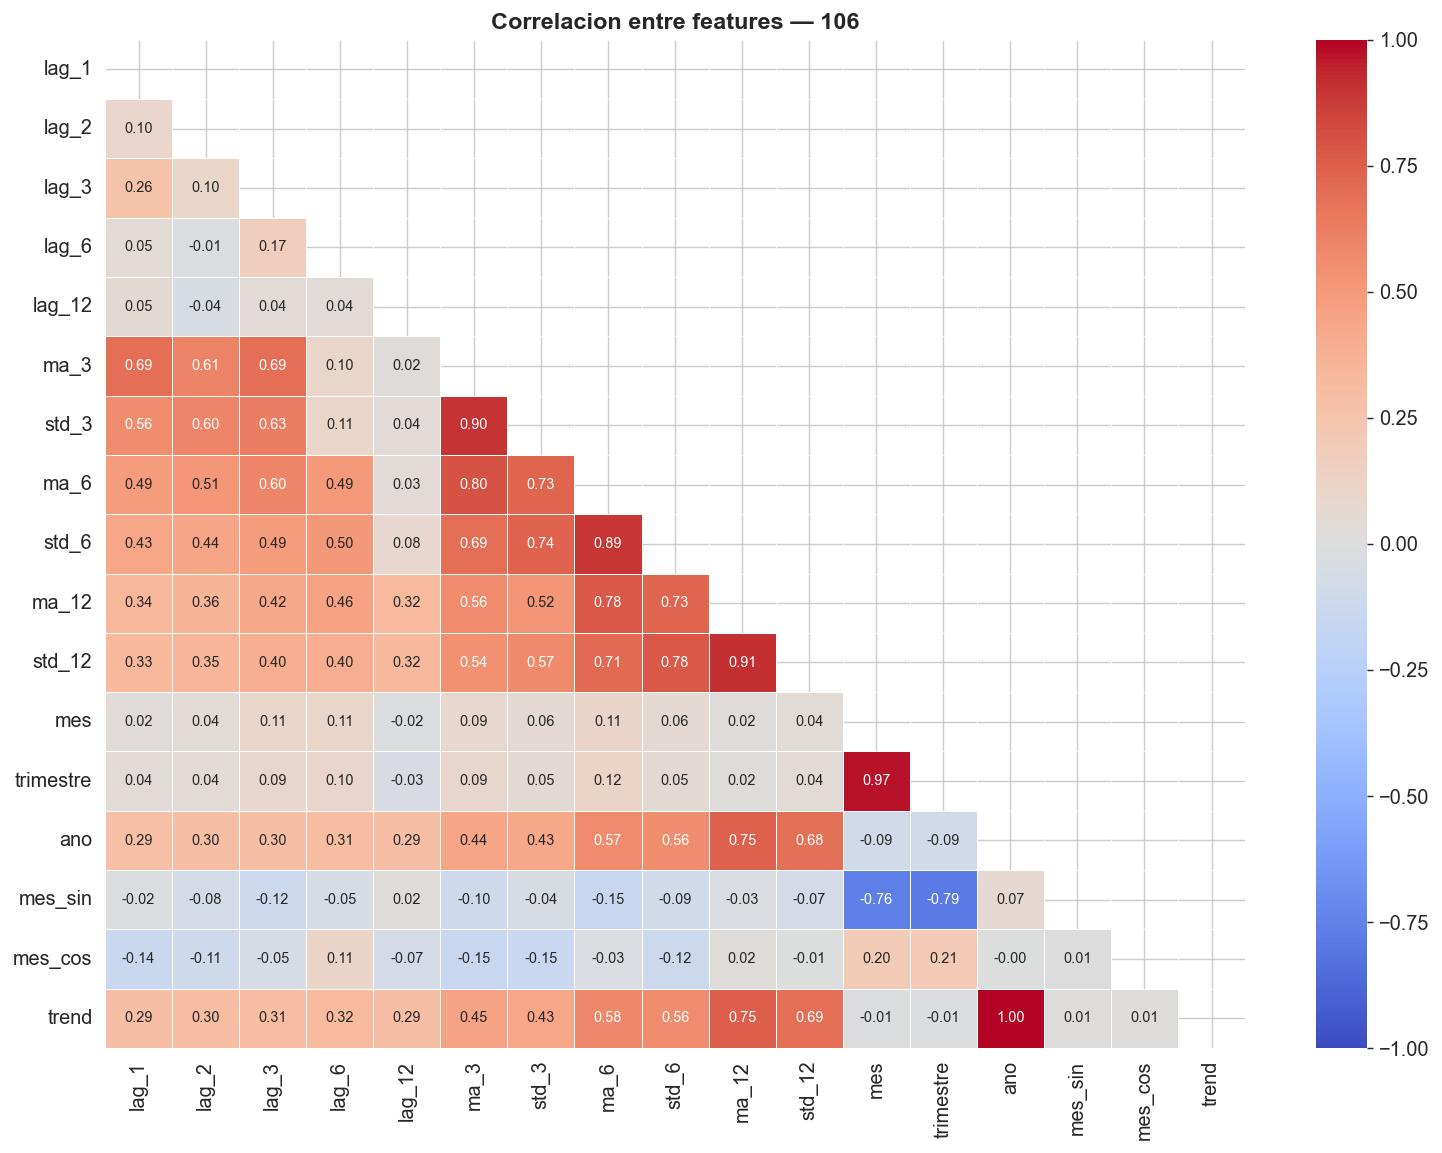

Figura guardada: figuras/04_correlacion_features.pdf


In [4]:
# Visualizar la matriz de correlacion de features (familia PVC como ejemplo)
familia_ej = FAMILIAS[0]
feat_corr  = datasets[familia_ej].drop(columns='y').corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(feat_corr, dtype=bool))
sns.heatmap(
    feat_corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, annot_kws={'size': 8}
)
plt.title(f'Correlacion entre features — {familia_ej}',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../figuras/04_correlacion_features.pdf', bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/04_correlacion_features.pdf')

## 3. Funciones auxiliares

In [5]:
def smape(actual, forecast):
    return 100 * np.mean(
        2 * np.abs(forecast - actual) / (np.abs(actual) + np.abs(forecast) + 1e-9)
    )

def calcular_metricas(actual, forecast, modelo, familia):
    return {
        'Modelo'  : modelo,
        'Familia' : familia,
        'RMSE'    : round(np.sqrt(mean_squared_error(actual, forecast)), 2),
        'MAE'     : round(mean_absolute_error(actual, forecast), 2),
        'MAPE_%'  : round(mean_absolute_percentage_error(actual, forecast) * 100, 2),
        'SMAPE_%' : round(smape(actual, forecast), 2),
    }


def forecast_recursivo(model, X_test, y_train_hist,
                        lags=[1, 2, 3, 6, 12], ventanas=[3, 6, 12]):
    """
    Prediccion recursiva multistep SIN data leakage.

    En cada paso h, los lags <= h se sustituyen por predicciones propias
    del modelo (no por el valor real, que no se conoceria en produccion).
    Los lags > h SI pueden usar historia real porque corresponden a
    meses ya observados en el momento de la prediccion (t = T).
    Las medias/std moviles se recalculan dinamicamente con la serie
    actualizada (historia + predicciones acumuladas).
    """
    history = list(y_train_hist.values)
    preds   = []
    n_steps = len(X_test)

    for step in range(n_steps):
        row = X_test.iloc[step].copy()

        for lag in lags:
            col = f'lag_{lag}'
            if col not in row.index:
                continue
            if lag <= step:
                row[col] = preds[step - lag]
            else:
                idx_hist = -(lag - step)
                row[col] = history[idx_hist]

        serie_actual = history + preds
        for v in ventanas:
            col_ma, col_std = f'ma_{v}', f'std_{v}'
            if col_ma in row.index:
                ventana = serie_actual[-v:]
                row[col_ma]  = np.mean(ventana)
                row[col_std] = np.std(ventana, ddof=1) if len(ventana) > 1 else 0

        pred = float(model.predict(row.values.reshape(1, -1))[0])
        preds.append(pred)

    return np.array(preds)


def bootstrap_intervals(model, X_train, y_train, X_test, fc_central,
                         n_boot=N_BOOT, alpha=ALPHA):
    """
    Intervalos de prediccion por bootstrap de residuos de TRAIN,
    centrados en la prediccion recursiva ya calculada (fc_central).
    """
    residuals = y_train.values - model.predict(X_train)
    lower, upper = [], []

    rng = np.random.default_rng(42)
    for i in range(len(fc_central)):
        boot = fc_central[i] + rng.choice(residuals, n_boot, replace=True)
        lower.append(np.percentile(boot, 100 * alpha / 2))
        upper.append(np.percentile(boot, 100 * (1 - alpha / 2)))

    return np.array(lower), np.array(upper)


print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


## 4. Tuning de hiperparámetros con TimeSeriesSplit

Usamos `RandomizedSearchCV` con `TimeSeriesSplit(n_splits=5)` como estrategia de CV.
Esto garantiza que cada fold de validacion siempre es temporalmente posterior
al fold de entrenamiento.

In [6]:
# ── Espacios de búsqueda de hiperparámetros por familia ──────────────────────
# Cada familia tiene un comportamiento estructural distinto:
#   106 = intermitente con eventos extremos -> regularización fuerte
#   124 = heterocedástica creciente         -> conservador, validado experimentalmente
#   233 = regular, tendencia suave          -> puede permitirse más flexibilidad
# Las claves se normalizan a string para evitar desajustes int/str.

param_dist_xgb_familias = {
    '106': {
        'n_estimators'    : [100, 150, 200],
        'max_depth'       : [2, 3],
        'learning_rate'   : [0.03, 0.05],
        'subsample'       : [0.7, 0.8],
        'colsample_bytree': [0.7, 0.8],
        'min_child_weight': [7, 9, 11],
        'reg_lambda'      : [3, 4, 5],
    },
    '124': {
        'n_estimators'    : [100, 150, 200],
        'max_depth'       : [2, 3, 4],
        'learning_rate'   : [0.03, 0.05, 0.07],
        'subsample'       : [0.7, 0.8],
        'colsample_bytree': [0.7, 0.8],
        'min_child_weight': [5, 7, 9],
        'reg_lambda'      : [2, 3, 4],
    },
    '233': {
        'n_estimators'    : [150, 200, 300],
        'max_depth'       : [3, 4, 5],
        'learning_rate'   : [0.05, 0.08, 0.1],
        'subsample'       : [0.8, 0.9],
        'colsample_bytree': [0.8, 0.9],
        'min_child_weight': [3, 5],
        'reg_lambda'      : [1, 2],
    },
}

param_dist_lgb_familias = {
    '106': {
        'n_estimators'    : [100, 150, 200],
        'max_depth'       : [2, 3],
        'learning_rate'   : [0.03, 0.05],
        'num_leaves'      : [7, 15],
        'subsample'       : [0.7, 0.8],
        'colsample_bytree': [0.7, 0.8],
        'min_child_samples': [20, 30, 40],
        'reg_alpha'       : [0.1, 0.5, 1.0],
        'reg_lambda'      : [0.1, 0.5, 1.0],
    },
    '124': {
        'n_estimators'    : [100, 150, 200],
        'max_depth'       : [2, 3, 4],
        'learning_rate'   : [0.03, 0.05, 0.07],
        'num_leaves'      : [7, 15, 31],
        'subsample'       : [0.7, 0.8],
        'colsample_bytree': [0.7, 0.8],
        'min_child_samples': [15, 20, 30],
        'reg_alpha'       : [0.01, 0.1, 0.5],
        'reg_lambda'      : [0.01, 0.1, 0.5],
    },
    '233': {
        'n_estimators'    : [150, 200, 300],
        'max_depth'       : [3, 4, 5],
        'learning_rate'   : [0.05, 0.08, 0.1],
        'num_leaves'      : [15, 31, 63],
        'subsample'       : [0.8, 0.9],
        'colsample_bytree': [0.8, 0.9],
        'min_child_samples': [10, 15, 20],
        'reg_alpha'       : [0, 0.01, 0.1],
        'reg_lambda'      : [0, 0.01, 0.1],
    },
}

tscv = TimeSeriesSplit(n_splits=5)
mejores_params = {'XGBoost': {}, 'LightGBM': {}}

for familia in FAMILIAS:
    familia_key = str(familia)   # normaliza a string para buscar en el dict

    if familia_key not in param_dist_xgb_familias:
        raise KeyError(
            f"No hay espacio de búsqueda definido para la familia '{familia_key}'. "
            f"Familias configuradas: {list(param_dist_xgb_familias.keys())}"
        )

    df_f_train = datasets_wins[familia]
    X_tr = df_f_train.drop(columns='y').iloc[:-H]
    y_tr = df_f_train['y'].iloc[:-H]

    print(f'\nTuning {familia}...')

    rscv_xgb = RandomizedSearchCV(
        xgb.XGBRegressor(random_state=42, verbosity=0),
        param_dist_xgb_familias[familia_key],
        n_iter=N_ITER, cv=tscv,
        scoring='neg_mean_absolute_percentage_error',
        random_state=42, n_jobs=-1
    )
    rscv_xgb.fit(X_tr, y_tr)
    mejores_params['XGBoost'][familia] = rscv_xgb.best_params_
    cv_mape_xgb = -rscv_xgb.best_score_ * 100
    print(f'  XGBoost  CV-MAPE={cv_mape_xgb:.2f}%  params={rscv_xgb.best_params_}')

    rscv_lgb = RandomizedSearchCV(
        lgb.LGBMRegressor(random_state=42, verbose=-1),
        param_dist_lgb_familias[familia_key],
        n_iter=N_ITER, cv=tscv,
        scoring='neg_mean_absolute_percentage_error',
        random_state=42, n_jobs=-1
    )
    rscv_lgb.fit(X_tr, y_tr)
    mejores_params['LightGBM'][familia] = rscv_lgb.best_params_
    cv_mape_lgb = -rscv_lgb.best_score_ * 100
    print(f'  LightGBM CV-MAPE={cv_mape_lgb:.2f}%  params={rscv_lgb.best_params_}')

print('\nTuning completado.')


Tuning 106...
  XGBoost  CV-MAPE=408507750442164355072.00%  params={'subsample': 0.7, 'reg_lambda': 3, 'n_estimators': 100, 'min_child_weight': 9, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
  LightGBM CV-MAPE=428457516552176926720.00%  params={'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0.5, 'num_leaves': 15, 'n_estimators': 100, 'min_child_samples': 40, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}

Tuning 124...
  XGBoost  CV-MAPE=265064419080912175104.00%  params={'subsample': 0.7, 'reg_lambda': 2, 'n_estimators': 100, 'min_child_weight': 9, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
  LightGBM CV-MAPE=224935338854388203520.00%  params={'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

Tuning 233...
  XGBoost  CV-MAPE=388286297596213395456.00%  params={'subsample': 0.8, 'reg_lambda': 1

## 5. Entrenamiento final y predicción walk-forward

In [7]:
resultados_xgb   = []
resultados_lgb   = []
predicciones_ml  = {}
modelos_xgb      = {}
modelos_lgb      = {}

for familia in FAMILIAS:
    df_f_train = datasets_wins[familia]   # ← wins para entrenar
    df_f_test  = datasets[familia]        # ← original para evaluar

    X_tr, y_tr = df_f_train.drop(columns='y').iloc[:-H], df_f_train['y'].iloc[:-H]
    X_te, y_te = df_f_test.drop(columns='y').iloc[-H:],  df_f_test['y'].iloc[-H:]

    predicciones_ml[familia] = {}

    for nombre, ModelClass, params in [
        ('XGBoost',  xgb.XGBRegressor,  {**mejores_params['XGBoost'][familia],
                                          'random_state': 42, 'verbosity': 0}),
        ('LightGBM', lgb.LGBMRegressor, {**mejores_params['LightGBM'][familia],
                                          'random_state': 42, 'verbose': -1}),
    ]:
        model = ModelClass(**params)
        model.fit(X_tr, y_tr)

        if nombre == 'XGBoost':
            modelos_xgb[familia] = model
        else:
            modelos_lgb[familia] = model

        y_pred = forecast_recursivo(model, X_te, y_tr, lags=[1, 2, 3, 6, 12, 24], ventanas=[3, 6, 12, 24])
        y_pred = np.clip(y_pred, 0, None)

        lo, hi = bootstrap_intervals(model, X_tr, y_tr, X_te, y_pred)  # ← y_pred añadido

        metricas = calcular_metricas(y_te.values, y_pred, nombre, familia)
        if nombre == 'XGBoost':
            resultados_xgb.append(metricas)
        else:
            resultados_lgb.append(metricas)

        predicciones_ml[familia][nombre] = {
            'test'     : y_te.values,
            'fc_mean'  : y_pred,
            'fc_lower' : lo,
            'fc_upper' : hi,
        }

        print(f'[{familia}] {nombre:8s}  '
              f'RMSE={metricas["RMSE"]:>10.2f}  '
              f'MAPE={metricas["MAPE_%"]:>6.2f}%  '
              f'SMAPE={metricas["SMAPE_%"]:>6.2f}%')

print('\nEntrenamiento y prediccion completados.')

[106] XGBoost   RMSE=  26704.62  MAPE=664.49%  SMAPE=113.38%
[106] LightGBM  RMSE=  26724.73  MAPE=608.38%  SMAPE=118.23%
[124] XGBoost   RMSE=  39437.36  MAPE= 46.09%  SMAPE= 65.27%
[124] LightGBM  RMSE=  36281.49  MAPE= 41.24%  SMAPE= 56.06%
[233] XGBoost   RMSE=  16665.50  MAPE= 48.03%  SMAPE= 43.18%
[233] LightGBM  RMSE=  17638.81  MAPE= 64.88%  SMAPE= 45.74%

Entrenamiento y prediccion completados.


## 6. Visualización de predicciones

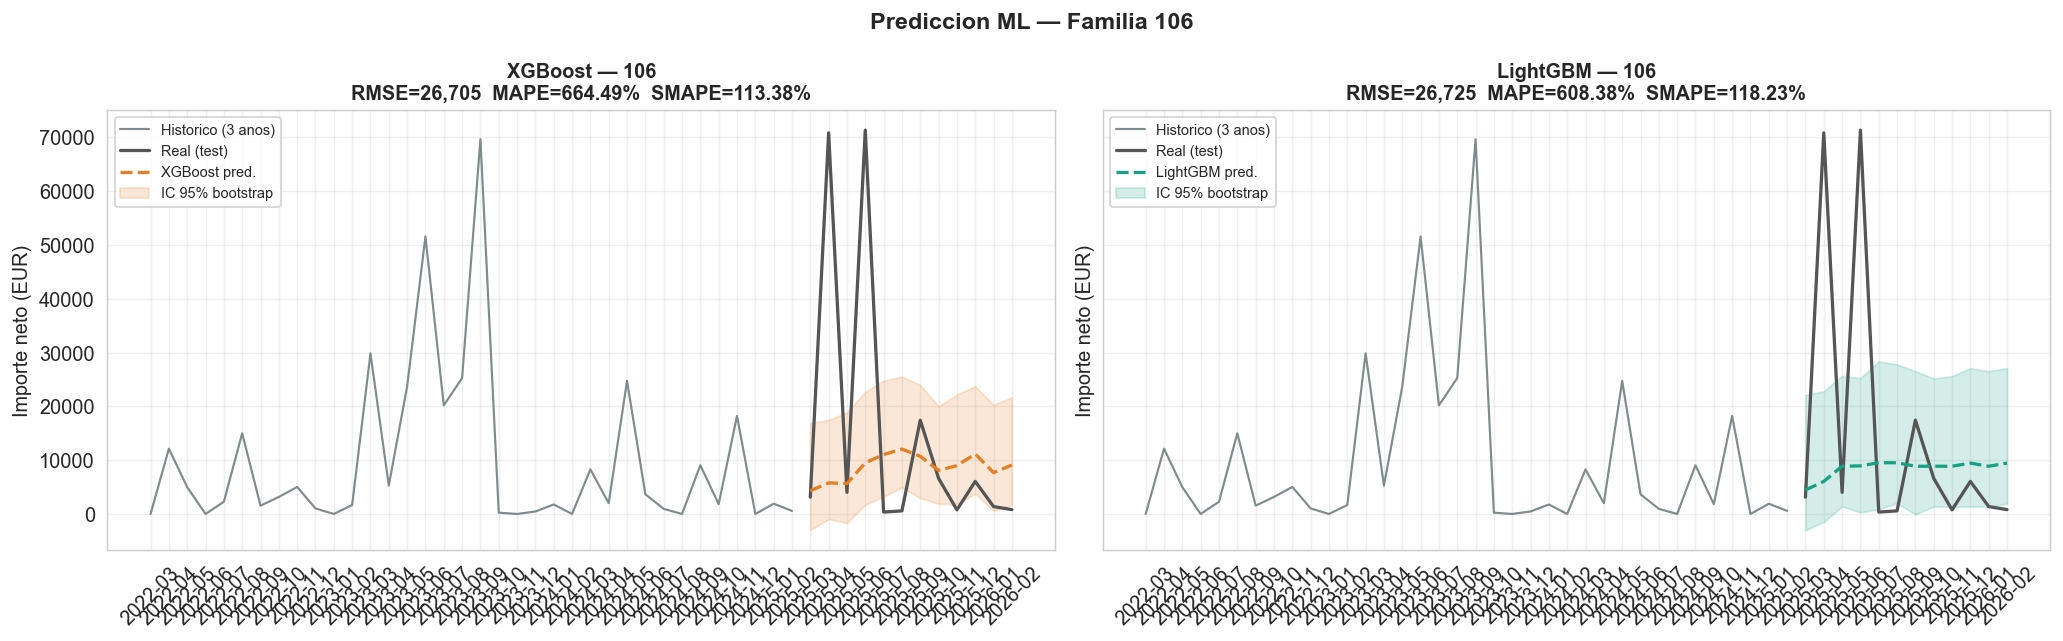

Figura guardada: ../figuras/04_prediccion_ML_106.pdf


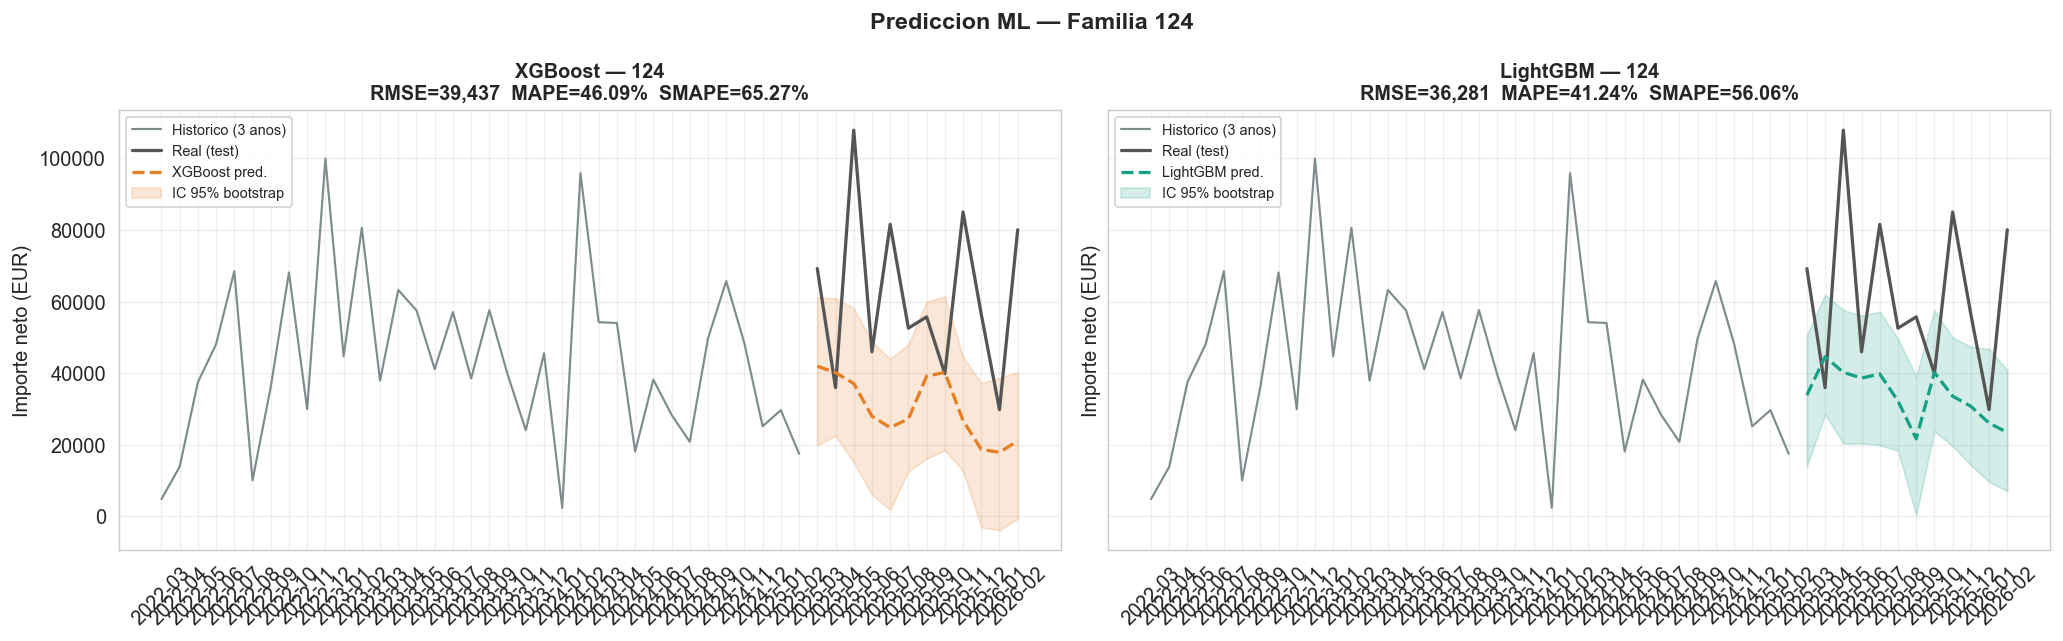

Figura guardada: ../figuras/04_prediccion_ML_124.pdf


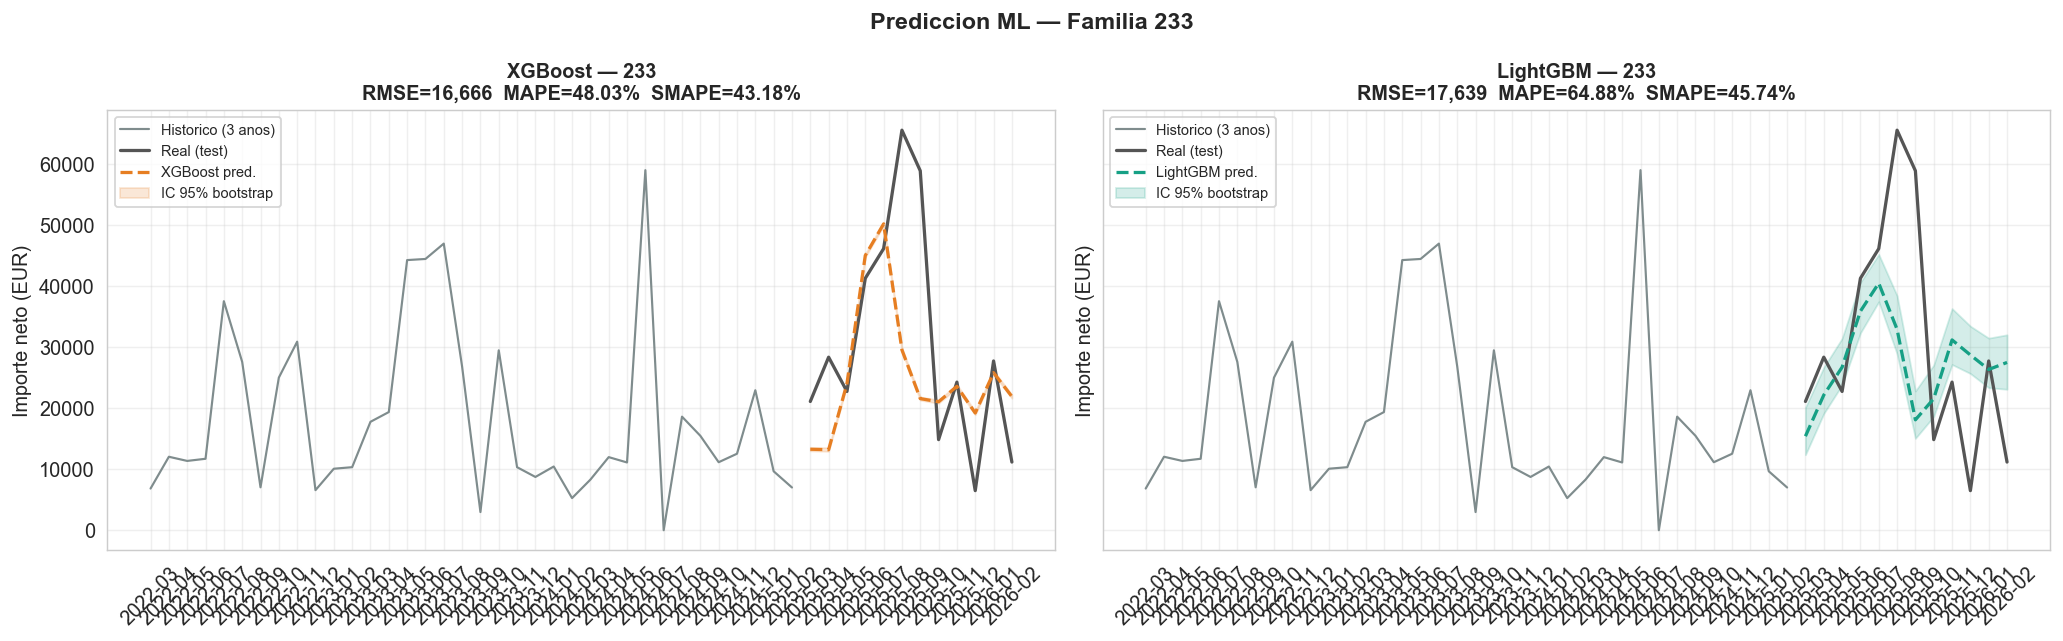

Figura guardada: ../figuras/04_prediccion_ML_233.pdf


In [8]:
MODELOS_COLORES = {'XGBoost': '#e67e22', 'LightGBM': '#16a085'}

for familia in FAMILIAS:
    serie    = ventas_mensual[familia].values
    n        = len(serie)
    test_idx = ventas_mensual.index[-H:].astype(str)

    ctx_start = n - H - 36
    ctx_idx   = ventas_mensual.index[ctx_start:].astype(str)
    ctx_train = serie[ctx_start:-H]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    for ax, nombre in zip(axes, ['XGBoost', 'LightGBM']):
        pred  = predicciones_ml[familia][nombre]
        color = MODELOS_COLORES[nombre]

        ax.plot(list(ctx_idx[:36]), ctx_train,
                color='#7f8c8d', lw=1.2, label='Historico (3 anos)')
        ax.plot(list(test_idx), pred['test'],
                color=COLORES.get(familia,'#555'), lw=1.8, label='Real (test)')
        ax.plot(list(test_idx), pred['fc_mean'],
                color=color, lw=1.8, ls='--', label=f'{nombre} pred.')
        ax.fill_between(list(test_idx),
                        pred['fc_lower'], pred['fc_upper'],
                        alpha=0.18, color=color,
                        label=f'IC {int((1-ALPHA)*100)}% bootstrap')

        res = resultados_xgb if nombre == 'XGBoost' else resultados_lgb
        m   = next(r for r in res if r['Familia'] == familia)
        ax.set_title(
            f'{nombre} — {familia}\n'
            f'RMSE={m["RMSE"]:,.0f}  MAPE={m["MAPE_%"]}%  SMAPE={m["SMAPE_%"]}%',
            fontweight='bold', fontsize=11
        )
        ax.set_ylabel('Importe neto (EUR)')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle(f'Prediccion ML — Familia {familia}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f'../figuras/04_prediccion_ML_{familia}.pdf'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {fname}')

## 7. Interpretabilidad con SHAP

Los valores SHAP (SHapley Additive exPlanations) cuantifican la contribucion
de cada feature a cada prediccion individual, con garantia de consistencia y
eficiencia (Lundberg & Lee, 2017).

Para modelos de árbol, `shap.TreeExplainer` calcula los valores exactos
en tiempo polinomial.

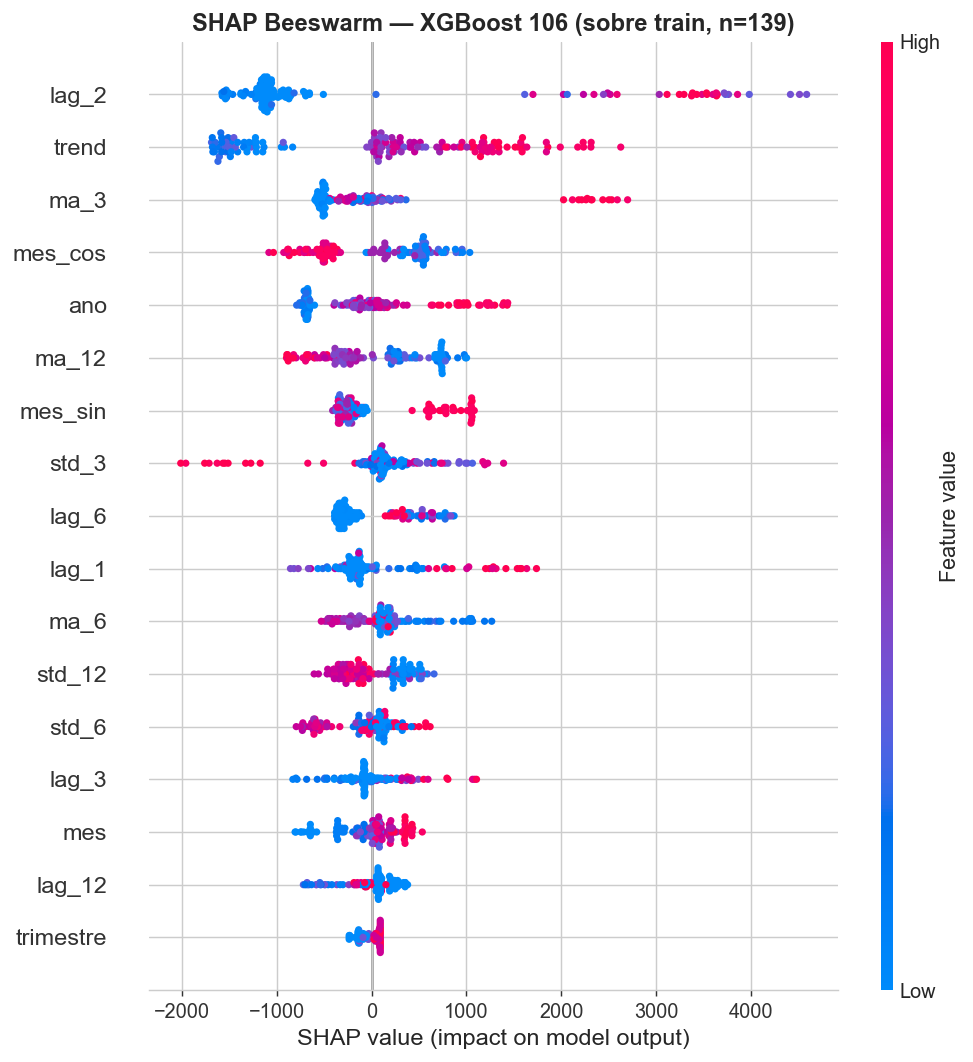

Figura guardada: ../figuras/05_shap_beeswarm_106.pdf


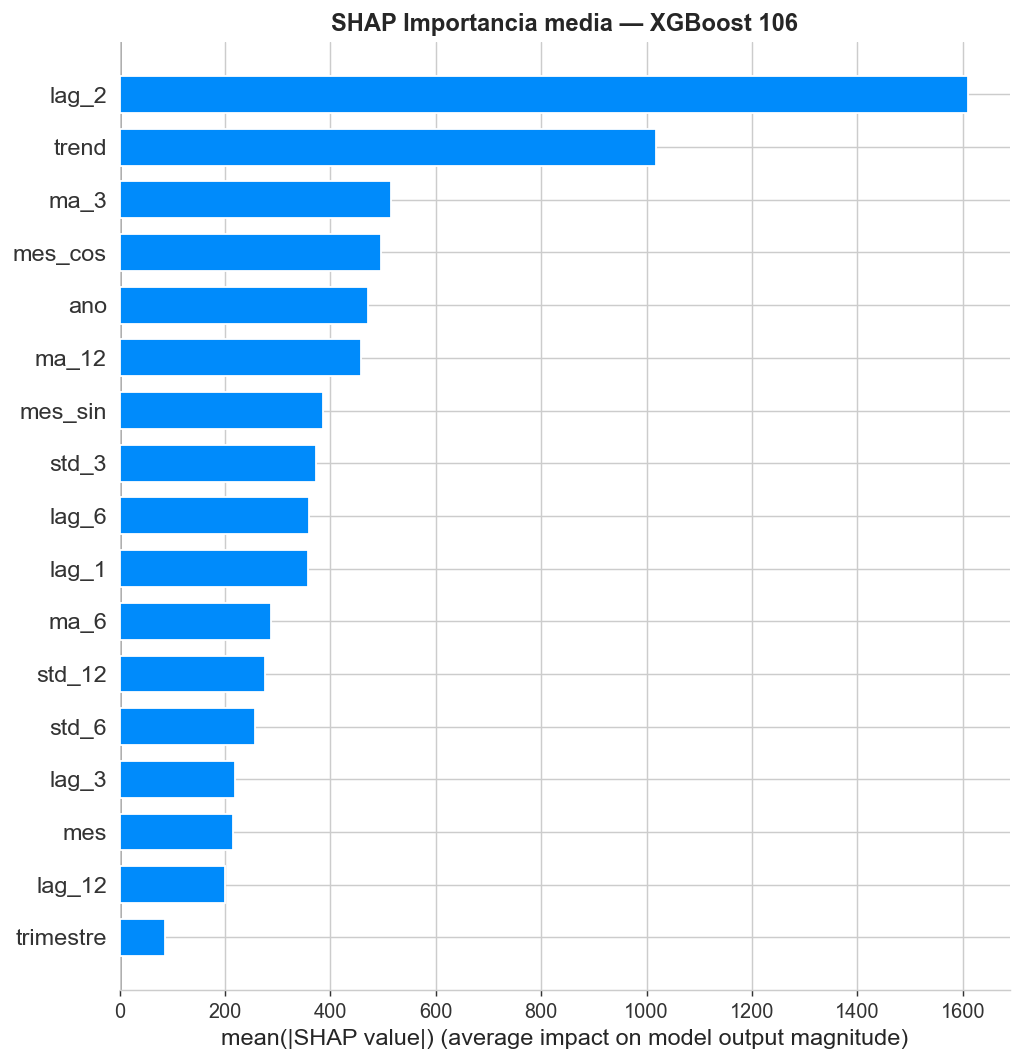

Figura guardada: ../figuras/05_shap_bar_106.pdf



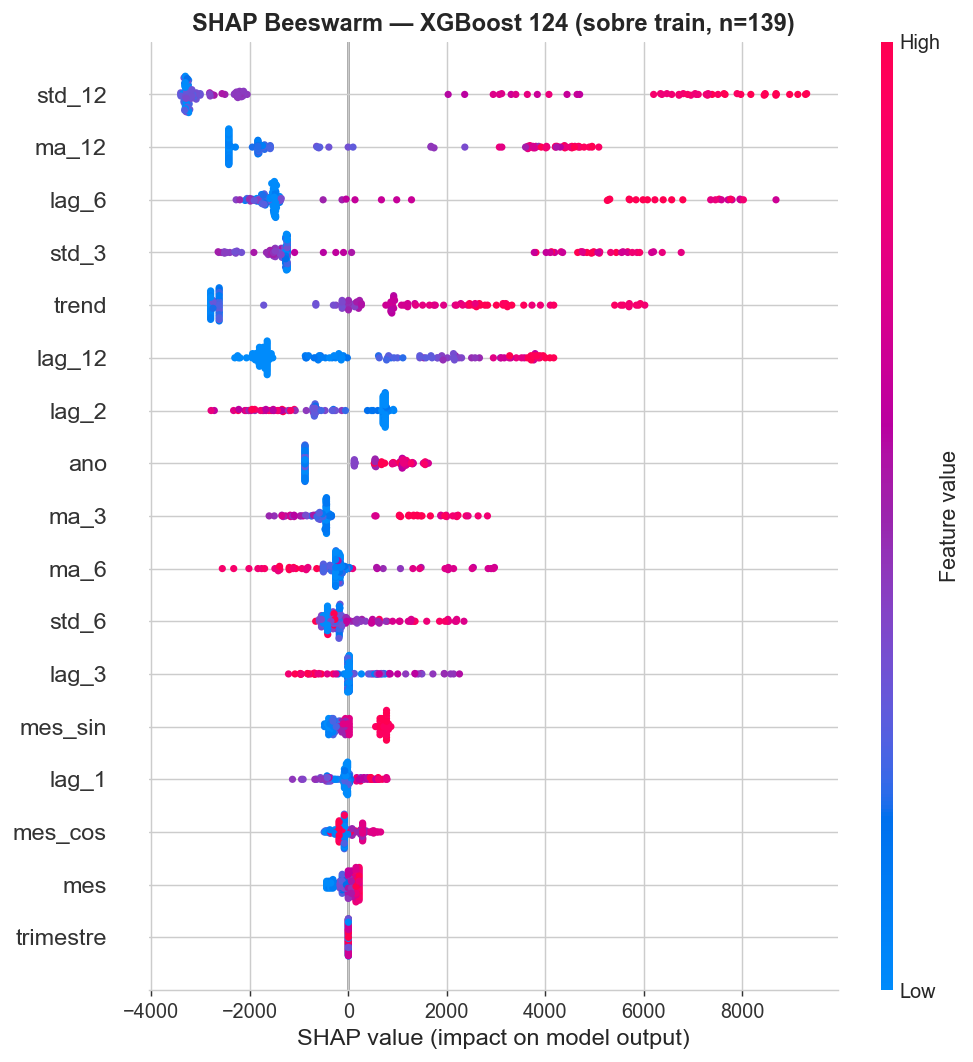

Figura guardada: ../figuras/05_shap_beeswarm_124.pdf


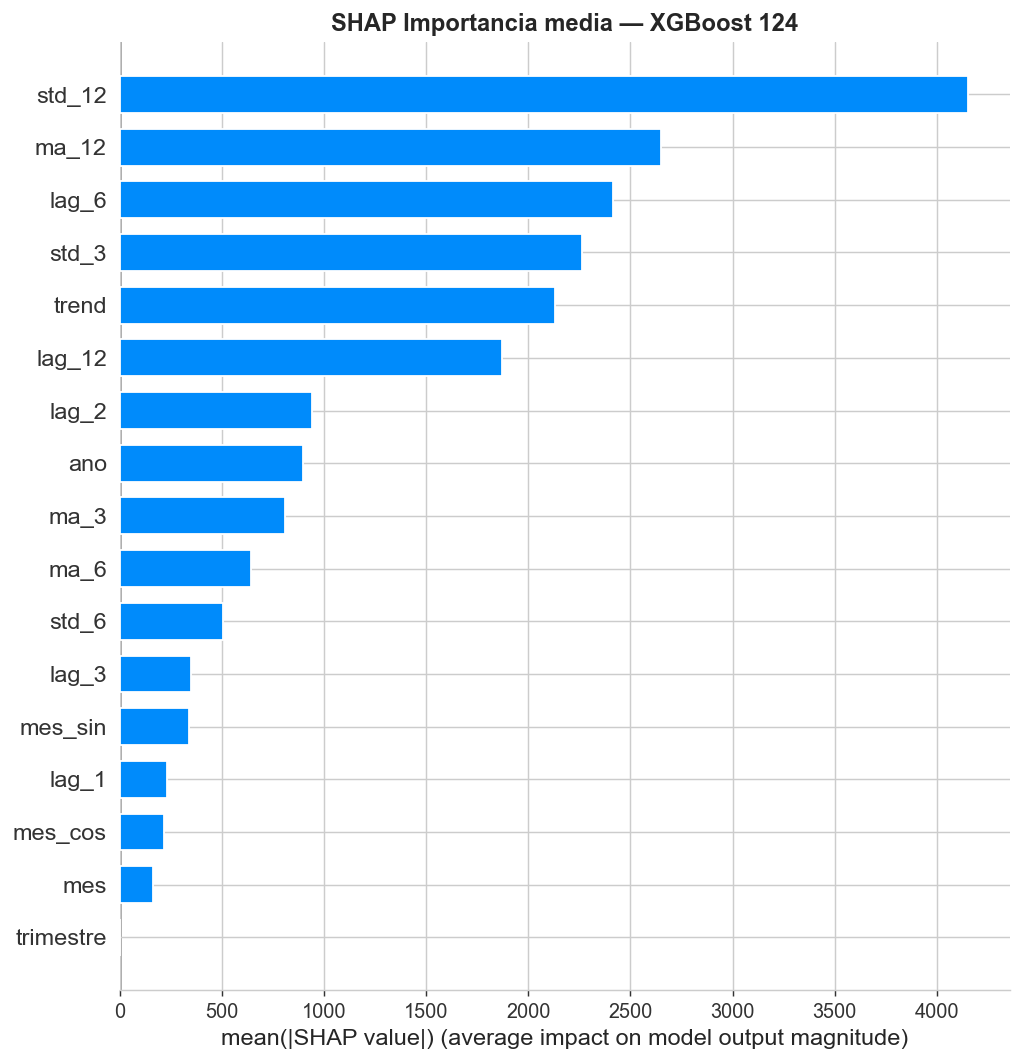

Figura guardada: ../figuras/05_shap_bar_124.pdf



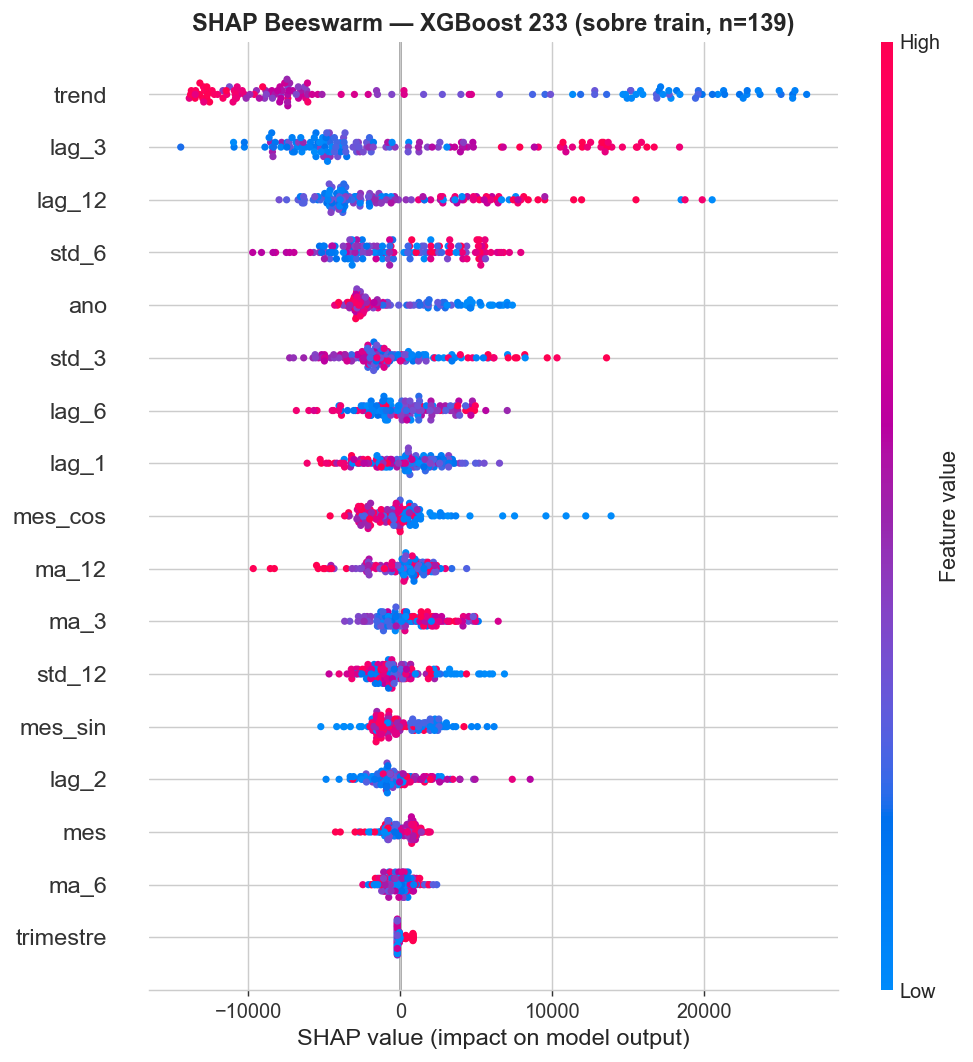

Figura guardada: ../figuras/05_shap_beeswarm_233.pdf


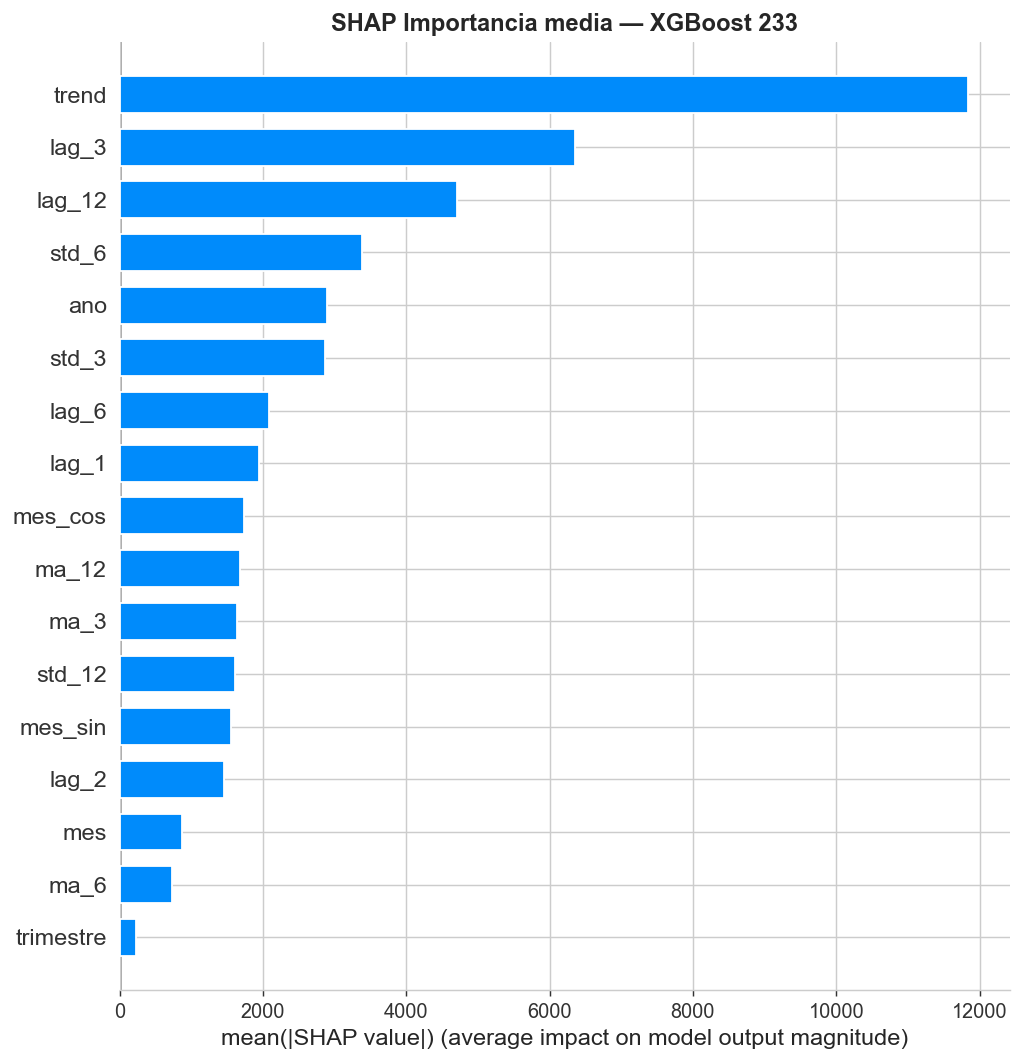

Figura guardada: ../figuras/05_shap_bar_233.pdf



In [11]:
shap_resultados = {}

for familia in FAMILIAS:
    df_f_train = datasets_wins[familia]   # mismo dataset que entrenó el modelo
    X_tr = df_f_train.drop(columns='y').iloc[:-H]
    model = modelos_xgb[familia]

    # Calcular SHAP sobre el conjunto de TRAIN (mucho más informativo que
    # los 12 puntos del test, y es coherente con los datos que vio el modelo)
    explainer  = shap.TreeExplainer(model)
    shap_vals  = explainer.shap_values(X_tr)
    shap_resultados[familia] = (shap_vals, X_tr)

    # -- Gráfico 1: Beeswarm (importancia + dirección del efecto) --
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_tr, show=False, plot_type='dot')
    plt.title(f'SHAP Beeswarm — XGBoost {familia} (sobre train, n={len(X_tr)})',
              fontweight='bold')
    plt.tight_layout()
    fname1 = f'../figuras/05_shap_beeswarm_{familia}.pdf'
    plt.savefig(fname1, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {fname1}')

    # -- Gráfico 2: Bar plot (importancia media absoluta) --
    plt.figure(figsize=(9, 5))
    shap.summary_plot(shap_vals, X_tr, show=False, plot_type='bar')
    plt.title(f'SHAP Importancia media — XGBoost {familia}', fontweight='bold')
    plt.tight_layout()
    fname2 = f'../figuras/05_shap_bar_{familia}.pdf'
    plt.savefig(fname2, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {fname2}\n')

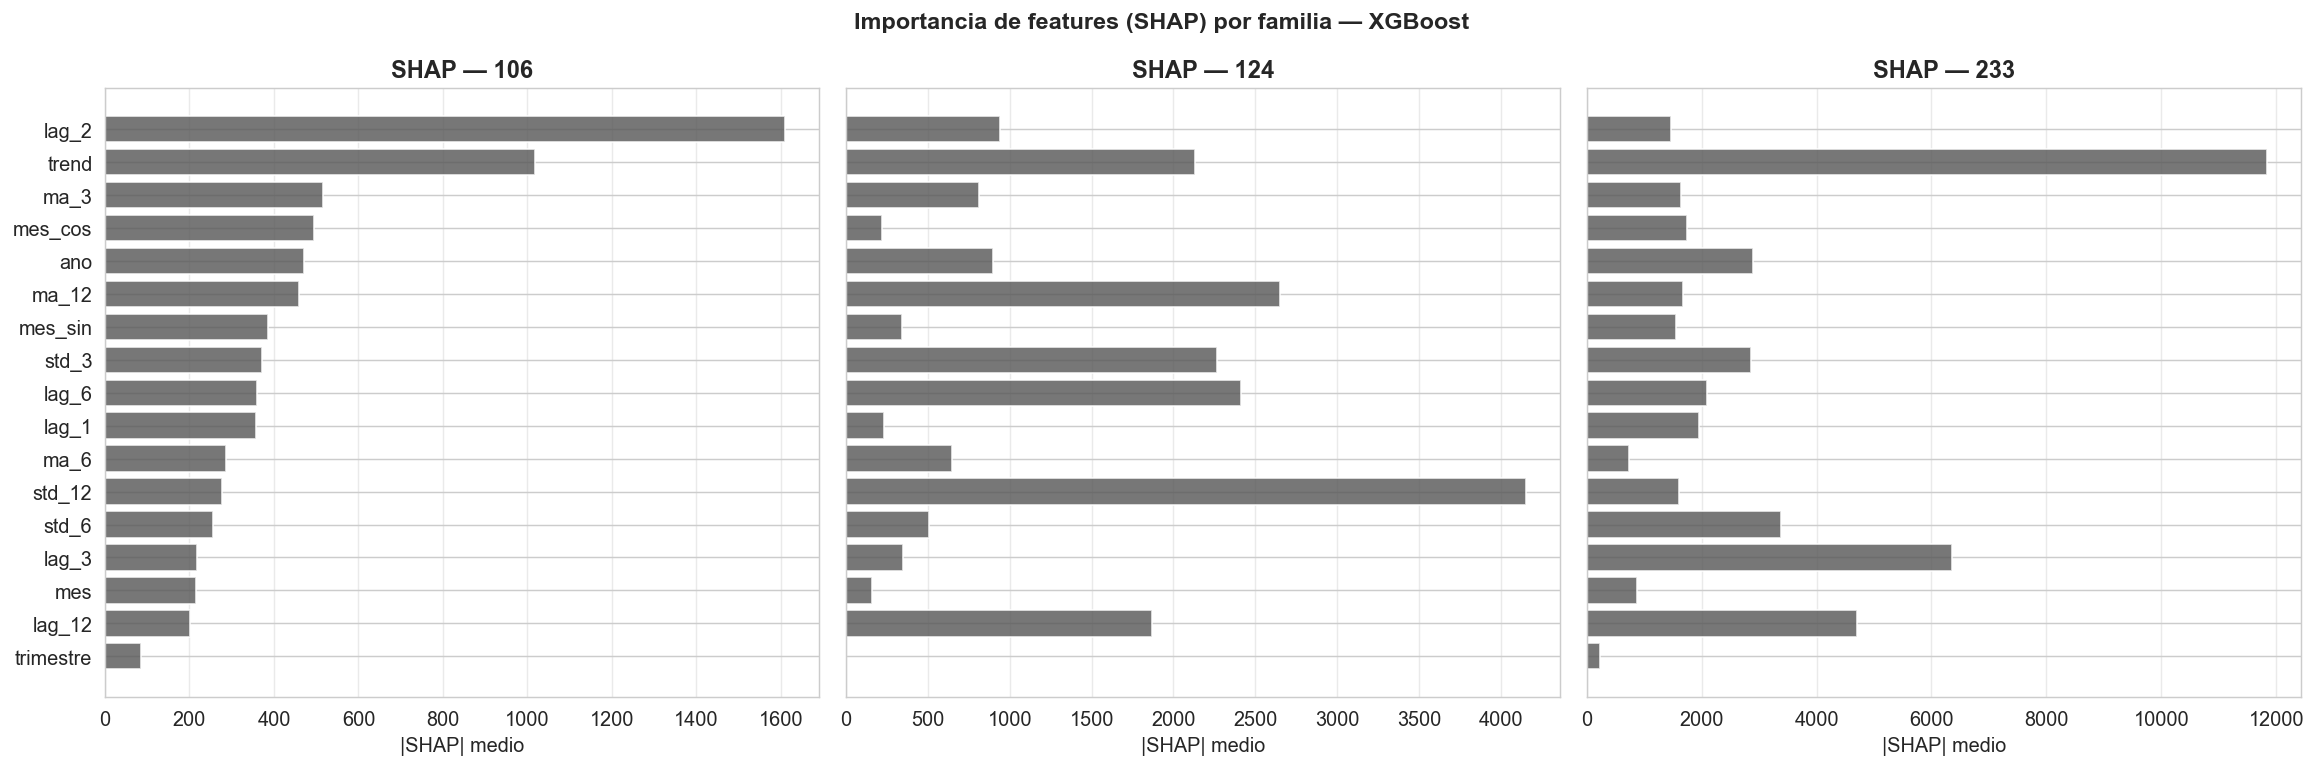

Figura guardada: figuras/05_shap_resumen.pdf


In [12]:
# Gráfico resumen: importancia SHAP media por feature y familia
fig, axes = plt.subplots(1, len(FAMILIAS),
                          figsize=(6 * len(FAMILIAS), 6), sharey=True)
if len(FAMILIAS) == 1:
    axes = [axes]

for ax, familia in zip(axes, FAMILIAS):
    shap_vals, X_tr = shap_resultados[familia]
    importancia = pd.Series(
        np.abs(shap_vals).mean(axis=0),
        index=X_tr.columns
    ).sort_values(ascending=True)

    color = COLORES.get(familia, '#555')
    ax.barh(importancia.index, importancia.values, color=color, alpha=0.8)
    ax.set_title(f'SHAP — {familia}', fontweight='bold')
    ax.set_xlabel('|SHAP| medio')
    ax.grid(axis='x', alpha=0.4)

plt.suptitle('Importancia de features (SHAP) por familia — XGBoost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figuras/05_shap_resumen.pdf', bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/05_shap_resumen.pdf')

## 8. Comparativa global con modelos del Notebook 03

In [18]:
import pandas as pd

# 1. Cargar métricas del Notebook 04 (SARIMA / Prophet)
try:
    df_04 = pd.read_csv('../data/processed/04_metricas_SARIMA_Prophet.csv')
except FileNotFoundError:
    print('AVISO: Ejecutar primero el Notebook 04 para tener las métricas de SARIMA/Prophet.')
    df_04 = pd.DataFrame(columns=['Modelo','Familia','RMSE','MAE','MAPE_%','SMAPE_%'])

# 2. Crear el DataFrame de Machine Learning del Notebook actual (XGB y LGBM)
df_ml = pd.DataFrame(resultados_xgb + resultados_lgb)

# 3. Concatenar los modelos estadísticos/Prophet con los de Machine Learning
df_global = pd.concat([df_04, df_ml], ignore_index=True)

# --- Tablas Pivot para visualización en el TFM ---

# Tabla pivot: familias x modelos, métrica = MAPE
tabla_mape = df_global.pivot_table(
    index='Familia', columns='Modelo', values='MAPE_%'
).round(2)

print('MAPE (%) — todos los modelos:')
print(tabla_mape.to_string())

# Tabla pivot: familias x modelos, métrica = SMAPE
tabla_smape = df_global.pivot_table(
    index='Familia', columns='Modelo', values='SMAPE_%'
).round(2)

print('\nSMAPE (%) — todos los modelos:')
print(tabla_smape.to_string())

# 4. Guardar el consolidado global definitivo
df_global.to_csv('../data/processed/05_metricas_global.csv', index=False)
print('\nCSV guardado: data/processed/05_metricas_global.csv')

MAPE (%) — todos los modelos:
Modelo   LightGBM  Prophet  SARIMA  XGBoost
Familia                                    
106        608.38   972.54  153.09   664.49
124         41.24    33.40   45.83    46.09
233         64.88    55.02   57.16    48.03

SMAPE (%) — todos los modelos:
Modelo   LightGBM  Prophet  SARIMA  XGBoost
Familia                                    
106        118.23   117.10  107.29   113.38
124         56.06    41.87   64.93    65.27
233         45.74    85.15   59.86    43.18

CSV guardado: data/processed/05_metricas_global.csv


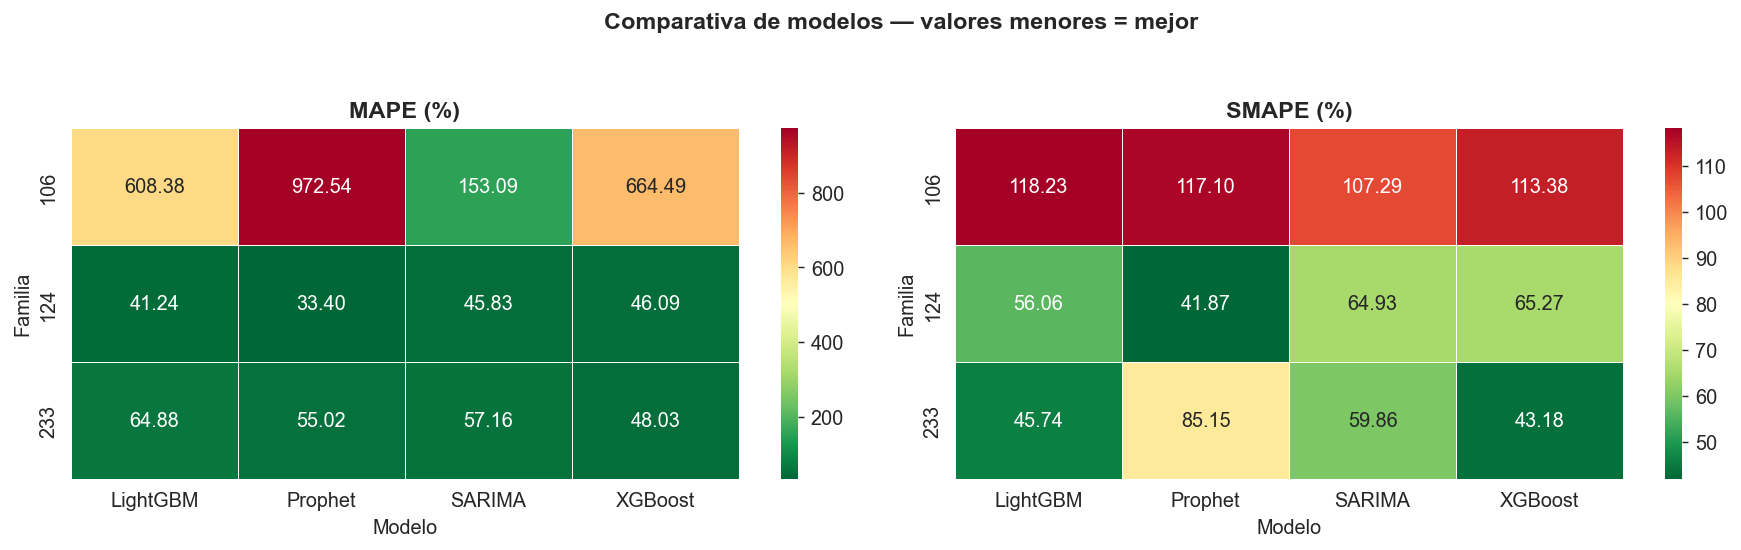

Figura guardada: figuras/05_heatmap_comparativa.pdf


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Aseguramos que los datos sean puramente numéricos antes de graficar
# (.apply(pd.to_numeric) convierte textos/objetos numéricos a float y los NaN se mantienen de forma nativa)
tabla_mape_num = tabla_mape.apply(pd.to_numeric, errors='coerce')
tabla_smape_num = tabla_smape.apply(pd.to_numeric, errors='coerce')

# Grafico heatmap de MAPE por familia y modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (titulo, tabla) in zip(axes, [
    ('MAPE (%)',  tabla_mape_num),
    ('SMAPE (%)', tabla_smape_num)
]):
    sns.heatmap(
        tabla, annot=True, fmt='.2f', cmap='RdYlGn_r',
        ax=ax, linewidths=0.5, annot_kws={'size': 11}
    )
    ax.set_title(titulo, fontweight='bold', fontsize=13)
    ax.set_xlabel('Modelo') # Añadido para dar claridad académica al eje X
    ax.set_ylabel('Familia') # Añadido para dar claridad académica al eje Y

plt.suptitle('Comparativa de modelos — valores menores = mejor',
             fontsize=13, fontweight='bold', y=1.05) # Subido un poco el título global para que no pise los sub-títulos
plt.tight_layout()
plt.savefig('../figuras/05_heatmap_comparativa.pdf', bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/05_heatmap_comparativa.pdf')

## 9. Exportación de predicciones

In [20]:
# Combinar predicciones XGBoost y LightGBM con las del Notebook 03
fechas_test = ventas_mensual.index[-H:].to_timestamp()
rows = []

for familia in FAMILIAS:
    for nombre in ['XGBoost', 'LightGBM']:
        pred = predicciones_ml[familia][nombre]
        for i, fecha in enumerate(fechas_test):
            rows.append({
                'FECHA'       : fecha,
                'FAMILIA'     : familia,
                'MODELO'      : nombre,
                'REAL'        : pred['test'][i],
                'PRED'        : pred['fc_mean'][i],
                'IC_LOWER'    : pred['fc_lower'][i],
                'IC_UPPER'    : pred['fc_upper'][i],
            })

df_pred_ml = pd.DataFrame(rows)
df_pred_ml.to_csv('../data/processed/05_predicciones_ML.csv', index=False)
print('Predicciones exportadas: data/processed/05_predicciones_ML.csv')
df_pred_ml.head(6)

Predicciones exportadas: data/processed/05_predicciones_ML.csv


,FECHA,FAMILIA,MODELO,REAL,PRED,IC_LOWER,IC_UPPER
0,2025-03-01,106,XGBoost,3125.12988,4332.388184,-3007.688965,16937.199157
1,2025-04-01,106,XGBoost,70852.02800,5779.609863,-925.099609,17472.868021
2,2025-05-01,106,XGBoost,4015.92000,5641.885742,-1698.191406,18864.224492
3,2025-06-01,106,XGBoost,71347.07600,9511.733398,1723.615234,22734.072148
4,2025-07-01,106,XGBoost,356.07000,11040.721680,3252.603516,24755.089031
5,2025-08-01,106,XGBoost,574.39500,12065.017578,4926.906250,25545.671344


In [21]:
print('=' * 65)
print('RESUMEN NOTEBOOK 05')
print('=' * 65)

for familia in FAMILIAS:
    mx = next(r for r in resultados_xgb if r['Familia'] == familia)
    ml = next(r for r in resultados_lgb if r['Familia'] == familia)
    print(f'\n[{familia}]')
    print(f'  XGBoost   RMSE={mx["RMSE"]:>10,.2f}  MAPE={mx["MAPE_%"]:>6.2f}%  SMAPE={mx["SMAPE_%"]:>6.2f}%')
    print(f'  LightGBM  RMSE={ml["RMSE"]:>10,.2f}  MAPE={ml["MAPE_%"]:>6.2f}%  SMAPE={ml["SMAPE_%"]:>6.2f}%')
    mejor = 'XGBoost' if mx['MAPE_%'] < ml['MAPE_%'] else 'LightGBM'
    print(f'  -> Mejor (MAPE): {mejor}')

print('\n' + '=' * 65)
print('Proximo: Notebook 06 — LSTM (Deep Learning)')

RESUMEN NOTEBOOK 05

[106]
  XGBoost   RMSE= 26,704.62  MAPE=664.49%  SMAPE=113.38%
  LightGBM  RMSE= 26,724.73  MAPE=608.38%  SMAPE=118.23%
  -> Mejor (MAPE): LightGBM

[124]
  XGBoost   RMSE= 39,437.36  MAPE= 46.09%  SMAPE= 65.27%
  LightGBM  RMSE= 36,281.49  MAPE= 41.24%  SMAPE= 56.06%
  -> Mejor (MAPE): LightGBM

[233]
  XGBoost   RMSE= 16,665.50  MAPE= 48.03%  SMAPE= 43.18%
  LightGBM  RMSE= 17,638.81  MAPE= 64.88%  SMAPE= 45.74%
  -> Mejor (MAPE): XGBoost

Proximo: Notebook 06 — LSTM (Deep Learning)
